In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'

from joblib import Parallel, delayed

from scipy.special import iv

import pickle

import schwingerModel as sim

In [10]:
with open('configs/50kSteps.pkl', 'rb') as f:
    temp = pickle.load(f)

In [11]:
m = temp.fMass
a = temp.a
dimx = temp.dimx
dimt = temp.dimt
beta = temp.beta
totalSteps = temp.metroSteps

print(m)
print(a)
print(dimx)
print(dimt)
print(beta)
print(totalSteps)

0.2
1
16
32
10
50000


In [12]:
#calculate pseudo-scalar mass for this lattice
bIn = 1000
skp = 50
correl = sim.distillation.correlStats(temp, burnIn=bIn,autocorrSkip=skp,nVec=4)
piv = 5
mass = sim.distillation.correlMassExtract(correl,fitT=[piv,18],diagCov=True)/temp.a
mass

configs:   0%|          | 0/980 [00:00<?, ?it/s]

array([5.56775908e-01, 3.26524795e-04])

In [13]:
bIn = 500
skp = 100

densities = []
mus = np.linspace(0,2*mass[0],30)
for mu in mus:
    print(mu, end=": \n")
    densities.append(sim.analysis.numDensityStats(temp,burnIn=bIn,autocorrSkip=skp, chemicalPot=mu))

0.0: 


100%|██████████| 495/495 [00:36<00:00, 13.69it/s]


0.03839833845323949: 


100%|██████████| 495/495 [00:36<00:00, 13.48it/s]


0.07679667690647898: 


...

100%|██████████| 495/495 [00:35<00:00, 13.90it/s]


1.0751534766907058: 


100%|██████████| 495/495 [00:36<00:00, 13.48it/s]


1.1135518151439452: 


100%|██████████| 495/495 [00:36<00:00, 13.66it/s]


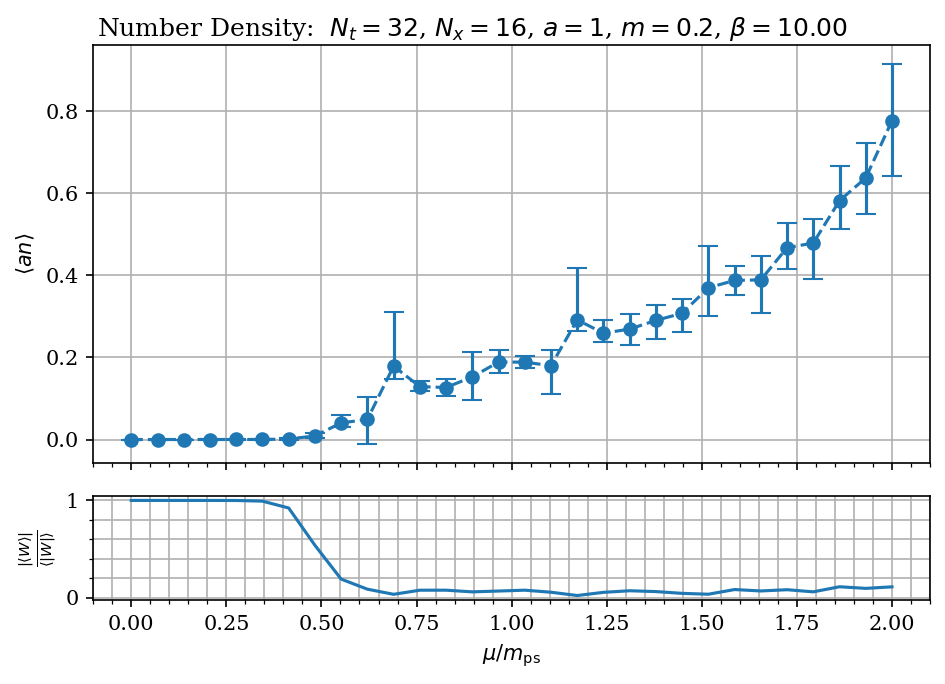

In [14]:
dens = np.array([densities[i][0] for i in range(len(densities))])
densErr = np.array([densities[i][1] for i in range(len(densities))]).T
validity = np.array([densities[i][2] for i in range(len(densities))])

fig, ax = plt.subplots(dpi=150, nrows=2, height_ratios=[4,1],sharex=True)

ax[0].errorbar(x=mus/mass[0],y=temp.a*dens,yerr=np.abs(densErr),capsize=5, marker="o",ls="--")
ax[0].set_ylabel(r"$\langle an\rangle$")
ax[0].grid()
ax[1].set_xlabel(r"$\mu/m_\text{ps}$")

ax[1].plot(mus/mass[0],validity)
ax[1].set_ylabel(r"$\frac{|\langle W\rangle|}{\langle |W| \rangle}$")
ax[1].minorticks_on()
ax[1].grid(which="both")

fig.suptitle(rf"Number Density:  $N_t = {dimt}$, $N_x={dimx}$, $a={a}$, $m={m}$, $\beta={beta:.2f}$",y=.94)
plt.tight_layout()